In [1]:
from dynamic import *

results = []  

for alpha in (0.25,0.5,0.6,0.7,0.8,0.9,0.95):
    for seed_val in range(10):
        print(f"seed={seed_val}, alpha={alpha}")
        trained_policy, steps = train(
            n=10, num_traj=50, m=50, eta=0.5, epsilon=1e-4,
            alpha=alpha,
            grid_size=8, danger=[3,3], goal=[0,6],
            horizon=50, coins=[(1,1),(1,3),(6,2)], seed=seed_val
        )
        results.append({
            "alpha": alpha,
            "seed": seed_val,
            "steps": steps,
            "policy": trained_policy
        })


seed=0, alpha=0.25
seed=1, alpha=0.25
seed=2, alpha=0.25
seed=3, alpha=0.25
seed=4, alpha=0.25
seed=5, alpha=0.25
seed=6, alpha=0.25
seed=7, alpha=0.25
seed=8, alpha=0.25
seed=9, alpha=0.25
seed=0, alpha=0.5
seed=1, alpha=0.5
seed=2, alpha=0.5
seed=3, alpha=0.5
seed=4, alpha=0.5
seed=5, alpha=0.5
seed=6, alpha=0.5
seed=7, alpha=0.5
seed=8, alpha=0.5
seed=9, alpha=0.5
seed=0, alpha=0.6
seed=1, alpha=0.6
seed=2, alpha=0.6
seed=3, alpha=0.6
seed=4, alpha=0.6
seed=5, alpha=0.6
seed=6, alpha=0.6
seed=7, alpha=0.6
seed=8, alpha=0.6
seed=9, alpha=0.6
seed=0, alpha=0.7
seed=1, alpha=0.7
seed=2, alpha=0.7
seed=3, alpha=0.7
seed=4, alpha=0.7
seed=5, alpha=0.7
seed=6, alpha=0.7
seed=7, alpha=0.7
seed=8, alpha=0.7
seed=9, alpha=0.7
seed=0, alpha=0.8
seed=1, alpha=0.8
seed=2, alpha=0.8
seed=3, alpha=0.8
seed=4, alpha=0.8
seed=5, alpha=0.8
seed=6, alpha=0.8
seed=7, alpha=0.8
seed=8, alpha=0.8
seed=9, alpha=0.8
seed=0, alpha=0.9
seed=1, alpha=0.9
seed=2, alpha=0.9
seed=3, alpha=0.9
seed=4, alpha=0.9


In [2]:
import pandas as pd
import pickle

results_dynamic = results

# suppose results_dynamic includes the Policy object
with open("results_dynamic.pkl", "wb") as f:
    pickle.dump(results_dynamic, f)

df_dyn = pd.DataFrame(results_dynamic)
print(df_dyn.head())


   alpha  seed  steps                                  policy
0   0.25     0   1182  <dynamic.Policy object at 0x1050524d0>
1   0.25     1   1190  <dynamic.Policy object at 0x13b12f510>
2   0.25     2   1182  <dynamic.Policy object at 0x13b157d90>
3   0.25     3   1167  <dynamic.Policy object at 0x13b227390>
4   0.25     4   1184  <dynamic.Policy object at 0x13b240d90>


In [3]:
summary_dyn = (
    df_dyn
    .groupby("alpha")["steps"]
    .agg(["mean", "std", "min", "max", "median", "count"])
    .reset_index()
)
print(summary_dyn)


   alpha    mean         std   min   max  median  count
0   0.25  1188.6   22.998551  1167  1248  1182.5     10
1   0.50  1074.0  413.824171   494  1817  1160.0     10
2   0.60   676.2  319.896094   368  1196   521.0     10
3   0.70   554.6  242.636079   321  1115   460.0     10
4   0.80   394.5   68.636320   335   534   372.5     10
5   0.90   448.4   44.644771   373   500   456.0     10
6   0.95   432.0   85.437436   320   580   414.0     10


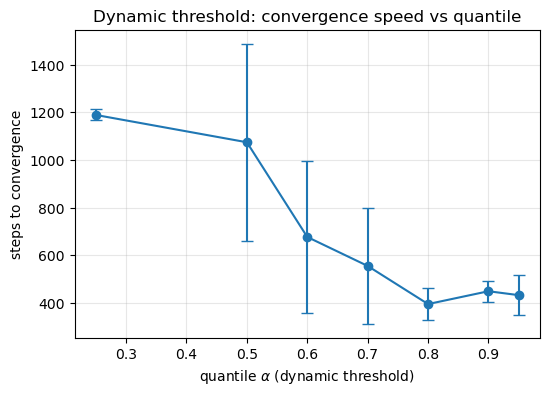

In [4]:
import matplotlib.pyplot as plt

alphas = summary_dyn["alpha"].values
means  = summary_dyn["mean"].values
stds   = summary_dyn["std"].values

plt.figure(figsize=(6,4))
plt.errorbar(alphas, means, yerr=stds, fmt='o-', capsize=4)
plt.xlabel(r"quantile $\alpha$ (dynamic threshold)")
plt.ylabel("steps to convergence")
plt.title("Dynamic threshold: convergence speed vs quantile")
plt.grid(True, alpha=0.3)
plt.show()


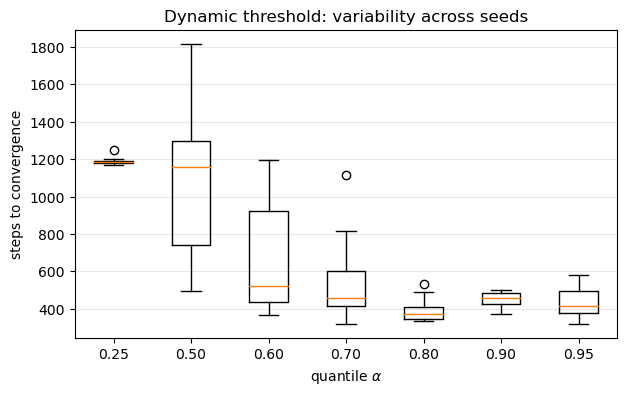

In [5]:
plt.figure(figsize=(7,4))
# Sort alphas so plots are ordered
alphas_sorted = sorted(df_dyn["alpha"].unique())
data = [df_dyn[df_dyn["alpha"] == a]["steps"].values for a in alphas_sorted]

plt.boxplot(data, positions=range(len(alphas_sorted)))
plt.xticks(range(len(alphas_sorted)), [f"{a:.2f}" for a in alphas_sorted])
plt.xlabel(r"quantile $\alpha$")
plt.ylabel("steps to convergence")
plt.title("Dynamic threshold: variability across seeds")
plt.grid(True, axis='y', alpha=0.3)
plt.show()


In [ ]:
results_dynamic

In [1]:
import pickle
import pandas as pd

from dynamic import *   # assumes train is imported from here

num_traj_values = [10, 25, 50, 75, 100, 150, 200]
seeds = list(range(10))

results_num_traj = []

for num_traj in num_traj_values:
    for seed_val in seeds:
        print(f"Running dynamic: num_traj={num_traj}, seed={seed_val}")

        trained_policy, steps = train(
            n=10,
            num_traj=num_traj,
            m=50,
            eta=0.5,
            epsilon=1e-4,
            alpha=0.8,
            grid_size=8,
            danger=[3, 3],
            goal=[0, 6],
            horizon=50,
            coins=[(1, 1), (1, 3), (6, 2)],
            seed=seed_val
        )

        policy_filename = f"policy_dynamic_numtraj{num_traj}_seed{seed_val}.pkl"
        with open(policy_filename, "wb") as f:
            pickle.dump(trained_policy, f)

        results_num_traj.append({
            "mode": "dynamic",
            "num_traj": num_traj,
            "seed": seed_val,
            "steps": steps,
            "policy_file": policy_filename
        })

df_dyn = pd.DataFrame(results_num_traj)
df_dyn.to_csv("dynamic_num_traj_results.csv", index=False)
print(df_dyn.head())


Running dynamic: num_traj=10, seed=0
Running dynamic: num_traj=10, seed=1
Running dynamic: num_traj=10, seed=2
Running dynamic: num_traj=10, seed=3
Running dynamic: num_traj=10, seed=4
Running dynamic: num_traj=10, seed=5
Running dynamic: num_traj=10, seed=6
Running dynamic: num_traj=10, seed=7
Running dynamic: num_traj=10, seed=8
Running dynamic: num_traj=10, seed=9
Running dynamic: num_traj=25, seed=0
Running dynamic: num_traj=25, seed=1
Running dynamic: num_traj=25, seed=2
Running dynamic: num_traj=25, seed=3
Running dynamic: num_traj=25, seed=4
Running dynamic: num_traj=25, seed=5
Running dynamic: num_traj=25, seed=6
Running dynamic: num_traj=25, seed=7
Running dynamic: num_traj=25, seed=8
Running dynamic: num_traj=25, seed=9
Running dynamic: num_traj=50, seed=0
Running dynamic: num_traj=50, seed=1
Running dynamic: num_traj=50, seed=2
Running dynamic: num_traj=50, seed=3
Running dynamic: num_traj=50, seed=4
Running dynamic: num_traj=50, seed=5
Running dynamic: num_traj=50, seed=6
R

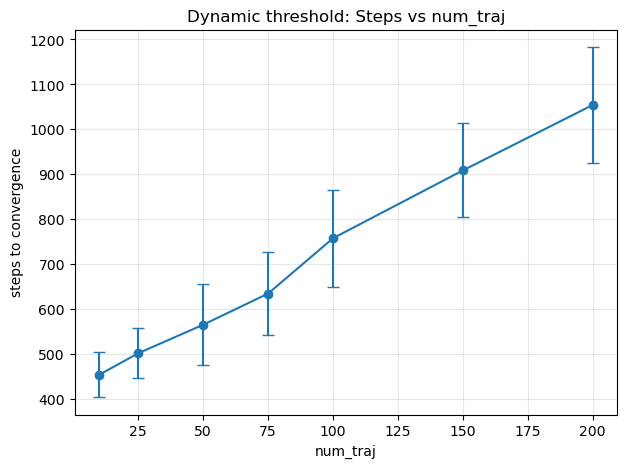

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

summary = df_dyn.groupby("num_traj")["steps"].agg(["mean", "std"]).reset_index()

# Plot mean ± std
plt.figure(figsize=(7, 5))
plt.errorbar(
    summary["num_traj"],
    summary["mean"],
    yerr=summary["std"],
    fmt="o-",
    capsize=4
)
plt.xlabel("num_traj")
plt.ylabel("steps to convergence")
plt.title("Dynamic threshold: Steps vs num_traj")
plt.grid(alpha=0.3)
plt.show()


In [3]:
print(df_dyn)

       mode  num_traj  seed  steps                          policy_file
0   dynamic        10     0    499   policy_dynamic_numtraj10_seed0.pkl
1   dynamic        10     1    457   policy_dynamic_numtraj10_seed1.pkl
2   dynamic        10     2    511   policy_dynamic_numtraj10_seed2.pkl
3   dynamic        10     3    491   policy_dynamic_numtraj10_seed3.pkl
4   dynamic        10     4    517   policy_dynamic_numtraj10_seed4.pkl
..      ...       ...   ...    ...                                  ...
65  dynamic       200     5   1177  policy_dynamic_numtraj200_seed5.pkl
66  dynamic       200     6    926  policy_dynamic_numtraj200_seed6.pkl
67  dynamic       200     7    980  policy_dynamic_numtraj200_seed7.pkl
68  dynamic       200     8    976  policy_dynamic_numtraj200_seed8.pkl
69  dynamic       200     9   1179  policy_dynamic_numtraj200_seed9.pkl

[70 rows x 5 columns]


In [4]:
def load_policy(filename):
    with open(filename, "rb") as f:
        policy = pickle.load(f)
    return policy



coin found at position: (1, 1)
coin found at position: (1, 3)
goal reached!
30


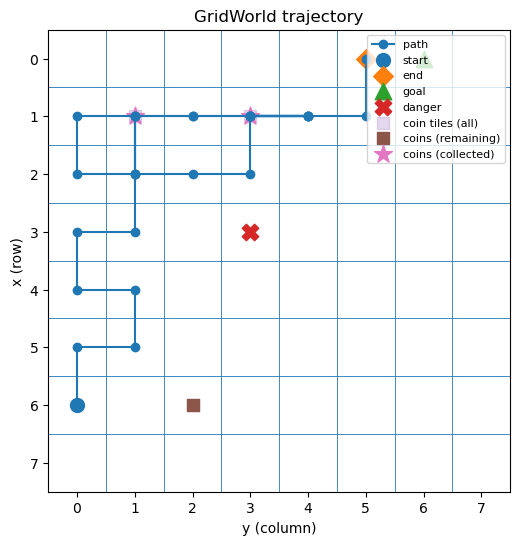

In [17]:
pi = load_policy("policy_dynamic_numtraj10_seed1.pkl")
import matplotlib.pyplot as plt

def plot_gridworld_path(env, states):
    size = env.size
    xs = [s[1] for s in states]
    ys = [s[0] for s in states]
    fig, ax = plt.subplots(figsize=(6, 6))
    for i in range(size + 1):
        ax.axhline(i - 0.5, linewidth=0.6)
        ax.axvline(i - 0.5, linewidth=0.6)
    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(-0.5, size - 0.5)
    ax.set_aspect('equal', adjustable='box')
    ax.invert_yaxis()
    ax.plot(xs, ys, marker='o', linewidth=1.5, label='path')
    if states:
        ax.scatter(xs[0], ys[0], marker='o', s=100, label='start')
        ax.scatter(xs[-1], ys[-1], marker='D', s=100, label='end')
    gx, gy = env.goal
    dx, dy = env.danger
    ax.scatter(gy, gx, marker='^', s=140, label='goal')     
    ax.scatter(dy, dx, marker='X', s=140, label='danger')
    init_coins = list(env._init_coins)
    remaining = list(env.coins)                
    collected = list(env.collected_coins)       

    if init_coins:
        ax.scatter([c[1] for c in init_coins], [c[0] for c in init_coins], marker='s', s=80, alpha=0.25, label='coin tiles (all)')

    if remaining:
        ax.scatter([c[1] for c in remaining], [c[0] for c in remaining], marker='s', s=80, label='coins (remaining)')

    if collected:
        ax.scatter([c[1] for c in collected], [c[0] for c in collected], marker='*', s=180, label='coins (collected)')

    ax.set_xticks(range(size))
    ax.set_yticks(range(size))
    ax.set_xlabel('y (column)')
    ax.set_ylabel('x (row)')
    ax.set_title('GridWorld trajectory')

    ax.legend(loc='upper right', fontsize=8)
    plt.show()

    
done = 0
traj = {"states": [], "actions": [], "steps": 0, "coins": 0}
env = GridWorld(7,size=8, danger=(3,3), goal=(0,6), coins=[(1,1),(1,3),(6,2)], horizon=50) ##set value of k here

s = env.reset() 
c = set([(1,1),(1,3),(6,2)])
while not done:
    a, _ = pi.act(s)
    traj["states"].append(s)
    traj["actions"].append(a)
    s, done = env.step(a)
    if (s in c):
        print(f"coin found at position: {s}")
        c.remove(s)
    if (s == env.goal):
        print("goal reached!")
    if (s == env.danger):
        print("danger zone")
print(env.t)

plot_gridworld_path(env, traj["states"])


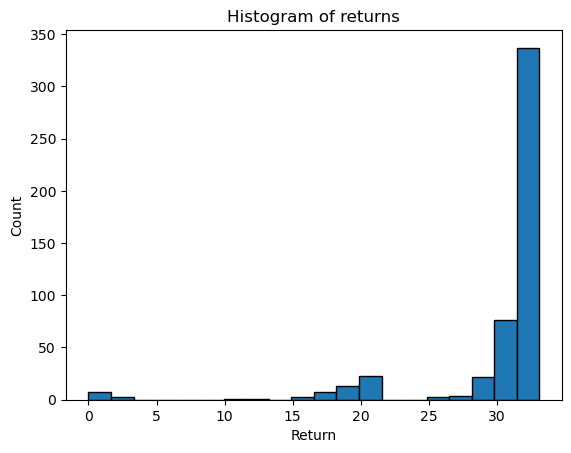

In [18]:
import matplotlib.pyplot as plt
def get_return():
    s = env.reset()
    done = False
    temp = []
    while not done:
        a, _ = pi.act(s)
        s, done = env.step(a)
    return env.true_return()

temp = []

for i in range(500):
    temp.append(get_return())
    
plt.hist(temp, bins=20, edgecolor='black')
plt.xlabel('Return')
plt.ylabel('Count')
plt.title('Histogram of returns')
plt.show()


In [9]:
results_num_traj

[{'mode': 'dynamic',
  'num_traj': 10,
  'seed': 0,
  'steps': 499,
  'policy_file': 'policy_dynamic_numtraj10_seed0.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 1,
  'steps': 457,
  'policy_file': 'policy_dynamic_numtraj10_seed1.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 2,
  'steps': 511,
  'policy_file': 'policy_dynamic_numtraj10_seed2.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 3,
  'steps': 491,
  'policy_file': 'policy_dynamic_numtraj10_seed3.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 4,
  'steps': 517,
  'policy_file': 'policy_dynamic_numtraj10_seed4.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 5,
  'steps': 435,
  'policy_file': 'policy_dynamic_numtraj10_seed5.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 6,
  'steps': 402,
  'policy_file': 'policy_dynamic_numtraj10_seed6.pkl'},
 {'mode': 'dynamic',
  'num_traj': 10,
  'seed': 7,
  'steps': 439,
  'policy_file': 'policy_dynamic_numtraj10_seed7.pkl'},
 {'mode'